# 2.1 Limpieza de datos



In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Carga de datos



In [12]:
df = pd.read_csv('./data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Información básica del dataset



In [13]:
df.sample(3)
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.")
df.info()

El shape del conjunto de entrenamiento es (891, 12). 891 filas y 12 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## Análisis de valores faltantes



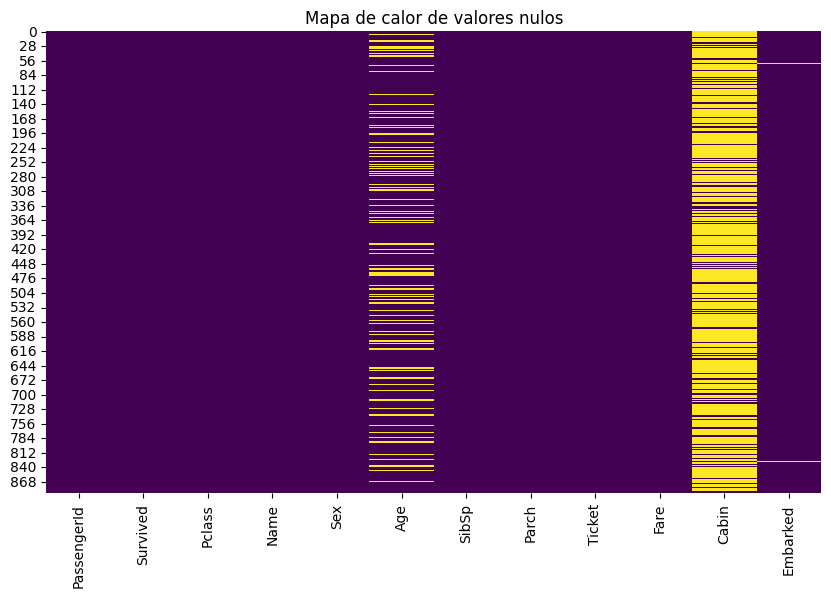

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64


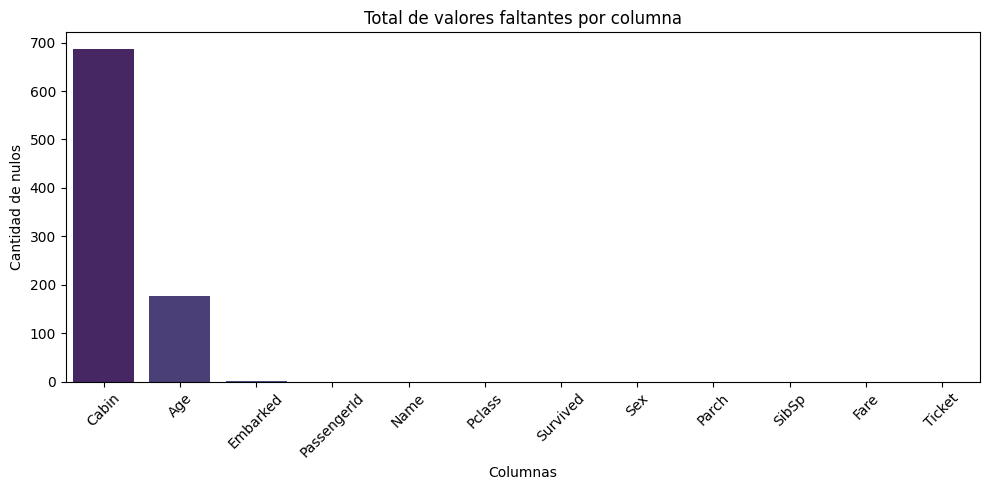

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

missing_values_percentage = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
print(missing_values_percentage)

missing_counts = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_counts.index, y=missing_counts.values, hue=missing_counts.index, palette='viridis', legend=False)
plt.title('Total de valores faltantes por columna')
plt.xticks(rotation=45)
plt.ylabel('Cantidad de nulos')
plt.xlabel('Columnas')
plt.tight_layout()
plt.show()

## Corrección de valores faltantes



In [15]:
df.drop('Cabin', axis=1, inplace=True)
mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print((df.isnull().sum().sort_values(ascending=False) / len(df) * 100).round(2))
print(df.isnull().sum())

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Valores duplicados y variables no útiles



In [16]:
print(f'Filas duplicadas: {df.duplicated().sum()}')

df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)
print(f"Después de limpiar df: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

Filas duplicadas: 0
Después de limpiar df: 891 filas y 8 columnas.


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Guardar datos limpios



In [17]:
df.to_csv('./data/titanic_clean.csv', index=False)
print('Archivo guardado en ./data/titanic_clean.csv')

Archivo guardado en ./data/titanic_clean.csv
